In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    version=3.0.1,
    description='Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.',
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=tf.uint8),
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=10),
    }),
    total_num_examples=70000,
    splits={
        'test': 10000,
        'train': 60000,
    },
    supervised_keys=('image', 'label'),
    citation="""@article{DBLP:journals/corr/abs-1708-07747,
      author    = {Han Xiao and
                   Kashif Rasul and
                   Roland Vollgraf},
      title     = {Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning
                   Algorithms},
      journal   = {CoRR},
      volume

In [ ]:
datos_entrenamiento, datos_prueba = datos['train'], datos['test']
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
#Normalización de los datos
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255
  return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_prueba = datos_prueba.map(normalizar)

datos_entrenamiento = datos_entrenamiento.cache()
datos_prueba = datos_prueba.cache()

tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(8, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(9, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(6, shape=(), dtype=int64)
tf.Tensor(9, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(7, shape=(), dtype=int64)
tf.Tensor(5, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(8, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(6, shape=(), dtype=int64)
tf.Tensor(7, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)


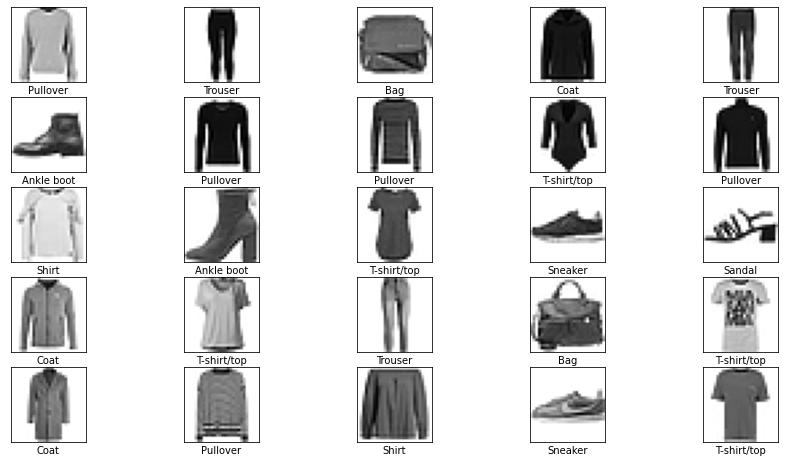

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  print(etiqueta)
  imagen = imagen.numpy().reshape((28, 28))
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary)
  plt.xlabel(nombres_clases[etiqueta])

plt.show()

In [ ]:
modelo = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)),
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax),
])

In [ ]:
modelo.compile(
    optimizer='Adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
num_datos_entrenamiento = metadatos.splits['train'].num_examples
num_datos_pruebas = metadatos.splits['test'].num_examples
tamano_lote = 32


datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_datos_entrenamiento).batch(tamano_lote)
datos_prueba = datos_prueba.batch(tamano_lote)

In [ ]:
import math


historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch=math.ceil(num_datos_entrenamiento/tamano_lote))

Epoch 1/5
1875/1875 [==============================] - 11s 2ms/step - loss: 0.5195 - accuracy: 0.8169
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3809 - accuracy: 0.8633
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3456 - accuracy: 0.8738
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3257 - accuracy: 0.8800
Epoch 5/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3092 - accuracy: 0.8837


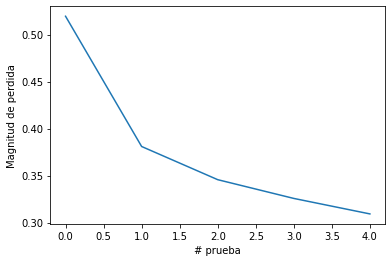

In [ ]:
plt.xlabel('# prueba')
plt.ylabel('Magnitud de perdida')
plt.plot(historial.history['loss'])

[[3.01901619e-05 2.06050657e-07 4.05730456e-02 1.18252192e-05
  9.17772114e-01 1.31940459e-09 4.16121930e-02 2.84545347e-08
  2.60136801e-07 1.45943289e-07]
 [4.97990595e-06 2.50418375e-09 1.41652012e-02 5.43523583e-06
  8.19954216e-01 3.12984777e-11 1.65870041e-01 1.48975582e-10
  9.61916129e-08 1.09843989e-09]
 [2.22753697e-05 1.16803778e-06 4.60209867e-06 4.32320985e-06
  5.69161202e-05 1.56012610e-01 2.51779766e-05 6.32902831e-02
  3.49328257e-05 7.80547738e-01]
 [6.00102013e-08 1.64197367e-09 6.42255387e-08 9.68815783e-09
  1.12704765e-06 8.07670469e-04 4.95780682e-07 7.38170266e-01
  9.36644653e-07 2.61019379e-01]
 [9.76833007e-07 1.55072177e-10 8.00192090e-09 1.79402093e-09
  7.44712807e-08 9.99989510e-01 1.08736636e-07 1.09670873e-06
  1.31746236e-09 8.19305205e-06]
 [3.77609999e-10 9.99999642e-01 2.86550922e-10 3.09423399e-07
  1.91315386e-09 7.17945235e-12 4.57242910e-10 2.07350404e-15
  5.04193798e-10 3.26500898e-13]
 [9.99514103e-01 2.44150344e-09 2.10646267e-05 1.21656612e

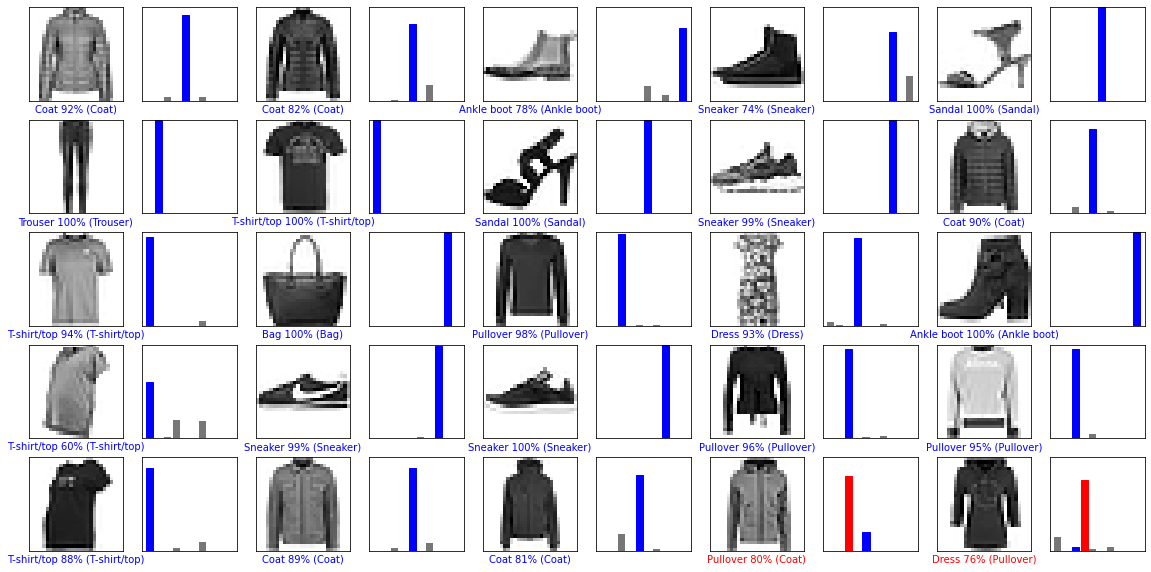

In [ ]:
#Pintar una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
import numpy as np

for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

print(predicciones)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                nombres_clases[etiqueta_real]),
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
  arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  grafica = plt.bar(range(10), arr_predicciones, color="#777777")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(arr_predicciones)

  grafica[etiqueta_prediccion].set_color('red')
  grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)